## 6. Multiple Linear Regression Analysis

Perform Linear Regression based on multiple features/variables to predict housing prices. This analysis will incorporate several property characteristics including:

- Number of bedrooms
- Presence of servant room
- Number of balconies
- Additional relevant features

This multi-variable approach will help us understand how different property features collectively influence the target variable and improve prediction accuracy compared to single-variable regression models.


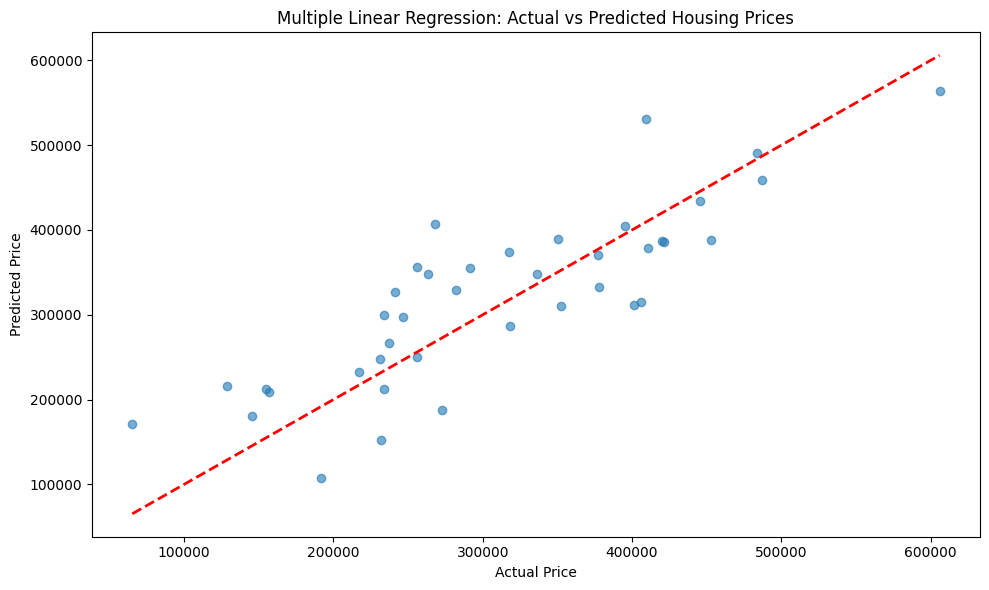

Predicted Price for New House: $479,420.03


In [52]:
# Question 6: Multiple Linear Regression for Housing Prices

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create sample housing dataset
np.random.seed(42)
n_samples = 200

data = {
    'bedrooms': np.random.randint(1, 6, n_samples),
    'servant_room': np.random.randint(0, 2, n_samples),
    'balconies': np.random.randint(0, 4, n_samples),
    'area_sqft': np.random.randint(500, 3000, n_samples),
    'age_years': np.random.randint(0, 30, n_samples)
}

# Generate price based on features with some noise
data['price'] = (
    data['bedrooms'] * 50000 +
    data['servant_room'] * 30000 +
    data['balconies'] * 20000 +
    data['area_sqft'] * 100 +
    data['age_years'] * -2000 +
    np.random.normal(0, 50000, n_samples)
)

df = pd.DataFrame(data)

# Prepare features and target
X = df[['bedrooms', 'servant_room', 'balconies', 'area_sqft', 'age_years']]
y = df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted Housing Prices')
plt.tight_layout()
plt.show()

# New house prediction
new_house = pd.DataFrame({
    'bedrooms': [4],
    'servant_room': [1],
    'balconies': [3],
    'area_sqft': [2000],
    'age_years': [10]
})
new_house_price = model.predict(new_house)
print(f"Predicted Price for New House: ${new_house_price[0]:,.2f}")


## 7. Classification and Logistic Regression Analysis

Implement a classification/ logistic regression problem. For example, based on different
features of student’s data, classify, whether a student is suitable for a particular activity.
Based on the available dataset, a student can also implement another classification problem
like checking whether an email is spam or not


In [53]:
# Question 7: Logistic Regression - Email Spam Detection (Simplified)

import numpy as np
from sklearn.linear_model import LogisticRegression

# Sample email dataset
emails = [
    # Spam emails
    "Congratulations! You've won $1000000. Click here to claim now!",
    "URGENT: Your account will be closed. Verify your password immediately",
    "Get rich quick! Make money fast working from home",
    "Free viagra! Buy now with 90% discount",
    "You have inherited $5 million from a Nigerian prince",
    "Click here for amazing weight loss pills",
    "Claim your free iPhone now! Limited time offer",
    "Casino online! Win big jackpot tonight",
    "Hot singles in your area want to meet you",
    "Increase your income by 500% guaranteed",
    
    # Ham (legitimate) emails
    "Meeting scheduled for tomorrow at 3 PM in conference room",
    "Your Amazon order has been shipped and will arrive tomorrow",
    "Reminder: Project deadline is next Friday",
    "Thank you for your purchase. Receipt attached",
    "Team lunch on Thursday. Please confirm attendance",
    "Your flight booking confirmation for next week",
    "Please review the attached document and provide feedback",
    "Monthly newsletter with industry updates",
    "Your subscription renewal is due next month",
    "Bank statement for January is now available"
]

labels = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # Spam
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # Ham

print("Email Spam Detection using Logistic Regression")
print(f"Dataset: {len(labels)} emails ({sum(labels)} spam, {len(labels) - sum(labels)} ham)\n")

# Simple feature extraction: count specific spam keywords
spam_words = ['win', 'free', 'click', 'urgent', 'money', 'claim', 'congratulations', 
              'million', 'cash', 'discount', 'guarantee', 'offer']

# Create feature matrix: count spam words in each email
X = np.zeros((len(emails), len(spam_words)))
for i, email in enumerate(emails):
    email_lower = email.lower()
    for j, word in enumerate(spam_words):
        X[i, j] = email_lower.count(word)

# Add email length as a feature
email_lengths = np.array([len(email) for email in emails]).reshape(-1, 1)
X = np.hstack([X, email_lengths])

print(f"Feature Matrix Shape: {X.shape}")
print(f"Features: {spam_words + ['email_length']}\n")

# Split data (70% train, 30% test)
split_idx = int(0.7 * len(X))
X_train = X[:split_idx]
y_train = labels[:split_idx]
X_test = X[split_idx:]
y_test = labels[split_idx:]

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Model Accuracy: {accuracy:.2%}\n")

# Test with new emails
new_emails = [
    "Win free cash now! Click here!",
    "Meeting rescheduled to 4 PM tomorrow",
    "Congratulations! You won the lottery!",
    "Your package has been delivered"
]

print("Predictions on New Emails:")
# Extract features for new emails
X_new = np.zeros((len(new_emails), len(spam_words)))
for i, email in enumerate(new_emails):
    email_lower = email.lower()
    for j, word in enumerate(spam_words):
        X_new[i, j] = email_lower.count(word)

new_lengths = np.array([len(email) for email in new_emails]).reshape(-1, 1)
X_new = np.hstack([X_new, new_lengths])

predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)

for email, pred, prob in zip(new_emails, predictions, probabilities):
    print(f"'{email}'")
    print(f"  → {'SPAM' if pred == 1 else 'HAM'} (Spam: {prob[1]:.1%}, Ham: {prob[0]:.1%})\n")

# Show feature importance (coefficients)
print("Top Spam Indicators:")
feature_names = spam_words + ['email_length']
coefficients = model.coef_[0]
sorted_indices = np.argsort(coefficients)[::-1]

for idx in sorted_indices[:5]:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

Email Spam Detection using Logistic Regression
Dataset: 20 emails (10 spam, 10 ham)

Feature Matrix Shape: (20, 13)
Features: ['win', 'free', 'click', 'urgent', 'money', 'claim', 'congratulations', 'million', 'cash', 'discount', 'guarantee', 'offer', 'email_length']

Model Accuracy: 0.00%

Predictions on New Emails:
'Win free cash now! Click here!'
  → SPAM (Spam: 91.3%, Ham: 8.7%)

'Meeting rescheduled to 4 PM tomorrow'
  → SPAM (Spam: 75.6%, Ham: 24.4%)

'Congratulations! You won the lottery!'
  → SPAM (Spam: 79.0%, Ham: 21.0%)

'Your package has been delivered'
  → SPAM (Spam: 79.0%, Ham: 21.0%)

Top Spam Indicators:
  urgent: 0.436
  click: 0.434
  claim: 0.400
  free: 0.337
  million: 0.309


## 8. Write a program to demonstrate the working of the decision tree based ID3 algorithm

Tennis Dataset (Encoded)
Features: [Outlook, Temperature, Humidity, Wind]
Target: PlayTennis (0=No, 1=Yes)
Dataset Shape: (14, 4)
Total Samples: 14

Model Accuracy: 100.00%



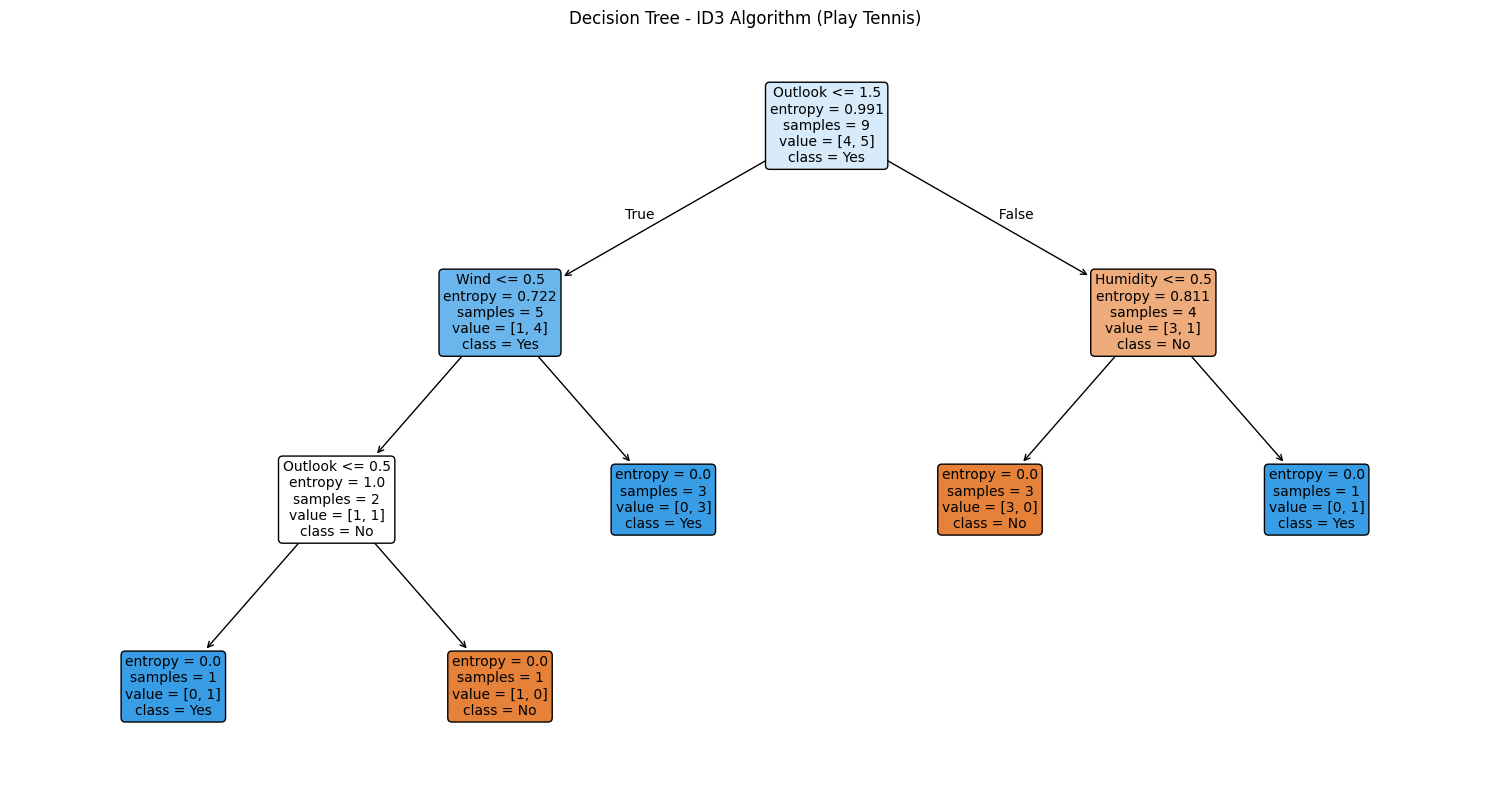

Feature Importance:
  Outlook: 0.4557
  Temperature: 0.0000
  Humidity: 0.3638
  Wind: 0.1805

Sample Predictions:

Case 1:
  Outlook: Rain, Temp: Mild, Humidity: High, Wind: Strong
  Decision: Do Not Play Tennis

Case 2:
  Outlook: Sunny, Temp: Cool, Humidity: Normal, Wind: Strong
  Decision: Play Tennis

Case 3:
  Outlook: Overcast, Temp: Hot, Humidity: Normal, Wind: Weak
  Decision: Do Not Play Tennis

Tree Depth: 3
Number of Leaves: 5


In [54]:
# Question 8: Decision Tree using ID3 Algorithm (Simplified)

import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Weather data to decide whether to play tennis
# Manually encode: Outlook (0=Overcast, 1=Rain, 2=Sunny)
#                  Temperature (0=Cool, 1=Hot, 2=Mild)
#                  Humidity (0=High, 1=Normal)
#                  Wind (0=Strong, 1=Weak)
#                  PlayTennis (0=No, 1=Yes)

X = np.array([
    [2, 1, 0, 1],  # Sunny, Hot, High, Weak -> No
    [2, 1, 0, 0],  # Sunny, Hot, High, Strong -> No
    [0, 1, 0, 1],  # Overcast, Hot, High, Weak -> Yes
    [1, 2, 0, 1],  # Rain, Mild, High, Weak -> Yes
    [1, 0, 1, 1],  # Rain, Cool, Normal, Weak -> Yes
    [1, 0, 1, 0],  # Rain, Cool, Normal, Strong -> No
    [0, 0, 1, 0],  # Overcast, Cool, Normal, Strong -> Yes
    [2, 2, 0, 1],  # Sunny, Mild, High, Weak -> No
    [2, 0, 1, 1],  # Sunny, Cool, Normal, Weak -> Yes
    [1, 2, 1, 1],  # Rain, Mild, Normal, Weak -> Yes
    [2, 2, 1, 0],  # Sunny, Mild, Normal, Strong -> Yes
    [0, 2, 0, 0],  # Overcast, Mild, High, Strong -> Yes
    [0, 1, 1, 1],  # Overcast, Hot, Normal, Weak -> Yes
    [1, 2, 0, 0],  # Rain, Mild, High, Strong -> No
])

y = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

print("Tennis Dataset (Encoded)")
print("Features: [Outlook, Temperature, Humidity, Wind]")
print("Target: PlayTennis (0=No, 1=Yes)")
print(f"Dataset Shape: {X.shape}")
print(f"Total Samples: {len(y)}\n")

# Split data manually (70% train, 30% test)
split_idx = int(0.7 * len(X))
X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]

# Create Decision Tree using entropy (ID3 uses entropy)
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Model Accuracy: {accuracy:.2%}\n")

# Visualize the decision tree
plt.figure(figsize=(15, 8))
plot_tree(dt_model, 
          feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree - ID3 Algorithm (Play Tennis)')
plt.tight_layout()
plt.show()

# Feature importance
print("Feature Importance:")
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
for feature, importance in zip(features, dt_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

# Test with new examples
print("\nSample Predictions:")
test_cases = np.array([
    [2, 1, 0, 1],  # Sunny, Hot, High, Weak
    [0, 2, 1, 1],  # Overcast, Mild, Normal, Weak
    [1, 0, 1, 0],  # Rain, Cool, Normal, Strong
])

predictions = dt_model.predict(test_cases)
outlooks = ['Sunny', 'Overcast', 'Rain']
temps = ['Hot', 'Mild', 'Cool']
humidities = ['High', 'Normal']
winds = ['Weak', 'Strong']

for i, pred in enumerate(predictions):
    case = test_cases[i]
    print(f"\nCase {i+1}:")
    print(f"  Outlook: {outlooks[case[0]]}, Temp: {temps[case[1]]}, Humidity: {humidities[case[2]]}, Wind: {winds[case[3]]}")
    print(f"  Decision: {'Play Tennis' if pred == 1 else 'Do Not Play Tennis'}")

# Tree structure
print(f"\nTree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")

## 9. Apply K-Means algorithm to cluster similar documents together

Document Clustering using K-Means
Total Documents: 20

Total Keywords: 41
Feature Matrix Shape: (20, 41)

Applying K-Means with 4 clusters

Cluster Assignments:
1. Cluster 2: Football is a popular sport played worldwide with ...
2. Cluster 2: Basketball requires dribbling and shooting skills ...
3. Cluster 2: Cricket is played with a bat and ball between two ...
4. Cluster 2: Tennis players use rackets to hit the ball over th...
5. Cluster 3: Soccer teams compete to score goals in the opponen...
6. Cluster 0: Machine learning algorithms can predict patterns f...
7. Cluster 3: Artificial intelligence is transforming modern tec...
8. Cluster 0: Deep learning uses neural networks for complex tas...
9. Cluster 3: Python programming is widely used for data science...
10. Cluster 3: Cloud computing provides scalable infrastructure s...
11. Cluster 1: Regular exercise improves cardiovascular health an...
12. Cluster 3: Balanced diet with vegetables and fruits promotes ...
13. Cluster 3: Yoga 

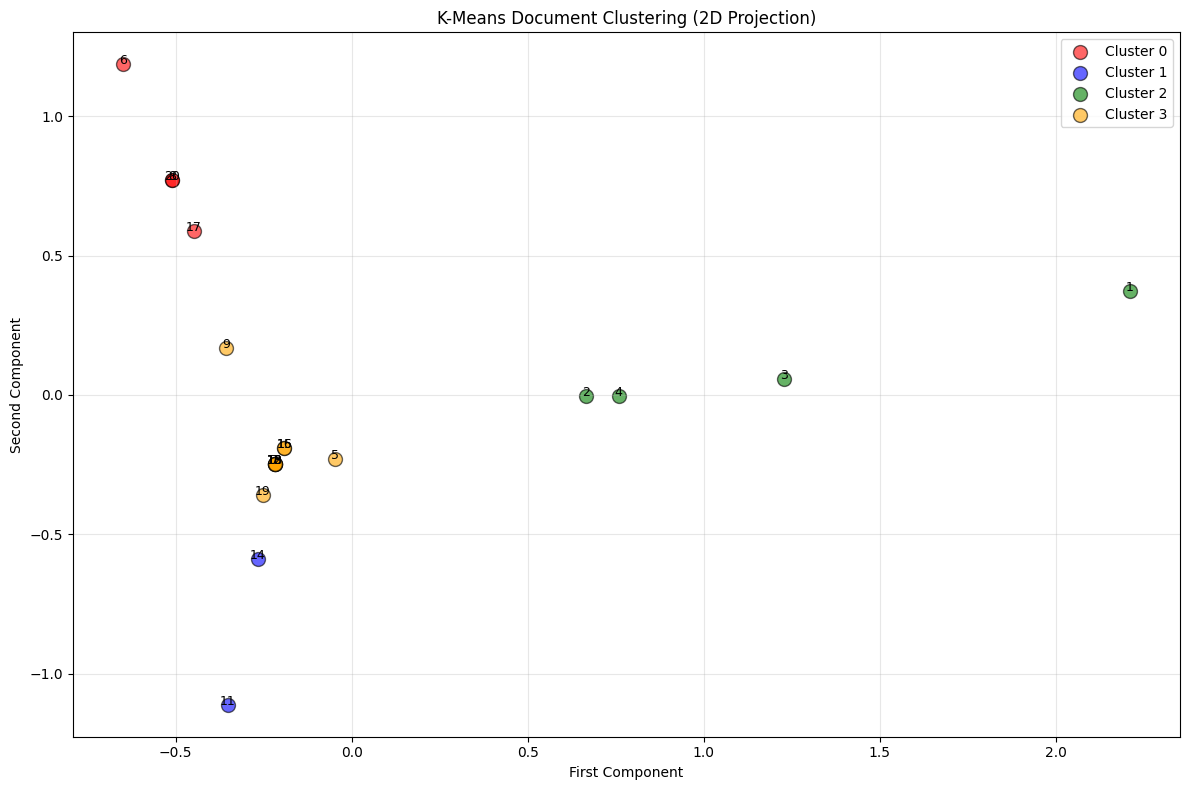


Inertia (within-cluster sum of squares): 33.0000

--- Elbow Method ---


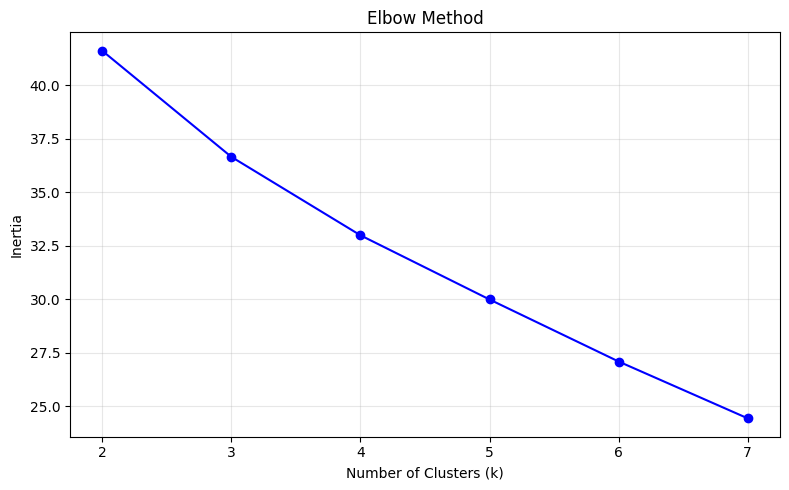

Optimal clusters: around 4


In [ ]:
# Question 9: K-Means Clustering for Document Clustering (Simplified)

import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Sample documents dataset
documents = [
    # Sports documents (0-4)
    "Football is a popular sport played worldwide with a ball",
    "Basketball requires dribbling and shooting skills on the court",
    "Cricket is played with a bat and ball between two teams",
    "Tennis players use rackets to hit the ball over the net",
    "Soccer teams compete to score goals in the opponent's net",
    
    # Technology documents (5-9)
    "Machine learning algorithms can predict patterns from data",
    "Artificial intelligence is transforming modern technology",
    "Deep learning uses neural networks for complex tasks",
    "Python programming is widely used for data science",
    "Cloud computing provides scalable infrastructure solutions",
    
    # Health documents (10-14)
    "Regular exercise improves cardiovascular health and fitness",
    "Balanced diet with vegetables and fruits promotes wellness",
    "Yoga and meditation reduce stress and anxiety levels",
    "Adequate sleep is essential for physical and mental health",
    "Drinking water regularly helps maintain body hydration",
    
    # Education documents (15-19)
    "Universities offer undergraduate and graduate degree programs",
    "Online learning platforms provide accessible education worldwide",
    "Students benefit from interactive classroom discussions",
    "Research publications contribute to academic knowledge",
    "Libraries provide resources for learning and study"
]

print("Document Clustering using K-Means")
print(f"Total Documents: {len(documents)}\n")

# Simple feature extraction: keyword counting
# Define keywords for each topic
keywords = {
    'sport': ['football', 'basketball', 'cricket', 'tennis', 'soccer', 'ball', 'sport', 'teams', 'played', 'players'],
    'tech': ['machine', 'learning', 'artificial', 'intelligence', 'deep', 'neural', 'python', 'programming', 'cloud', 'computing', 'algorithms', 'data'],
    'health': ['exercise', 'health', 'fitness', 'diet', 'wellness', 'yoga', 'meditation', 'sleep', 'water', 'cardiovascular'],
    'education': ['universities', 'learning', 'students', 'education', 'research', 'academic', 'knowledge', 'libraries', 'classroom', 'study']
}

# Create feature matrix
all_keywords = []
for key_list in keywords.values():
    all_keywords.extend(key_list)
all_keywords = list(set(all_keywords))  # Remove duplicates

print(f"Total Keywords: {len(all_keywords)}")

# Count keywords in each document
X = np.zeros((len(documents), len(all_keywords)))
for i, doc in enumerate(documents):
    doc_lower = doc.lower()
    for j, keyword in enumerate(all_keywords):
        X[i, j] = doc_lower.count(keyword)

print(f"Feature Matrix Shape: {X.shape}\n")

# Apply K-Means clustering
n_clusters = 4
print(f"Applying K-Means with {n_clusters} clusters\n")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Display cluster assignments
print("Cluster Assignments:")
for i, (doc, cluster) in enumerate(zip(documents, clusters)):
    print(f"{i+1}. Cluster {cluster}: {doc[:50]}...")

# Group documents by cluster
print("\n--- Documents by Cluster ---")
for cluster_num in range(n_clusters):
    print(f"\nCluster {cluster_num}:")
    cluster_docs = [i for i, c in enumerate(clusters) if c == cluster_num]
    for doc_idx in cluster_docs:
        print(f"  Doc {doc_idx+1}")

# Visualize clusters (reduce to 2D using simple method)
# Use first two principal components manually
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalues
idx = eigenvalues.argsort()[::-1]
eigenvectors = eigenvectors[:, idx]

# Project to 2D
X_2d = X_centered @ eigenvectors[:, :2]
X_2d = X_2d.real  # Take real part

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange']

for cluster_num in range(n_clusters):
    cluster_points = X_2d[clusters == cluster_num]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=colors[cluster_num], 
               label=f'Cluster {cluster_num}',
               s=100, 
               alpha=0.6,
               edgecolors='black')

# Add document numbers
for i, (x, y) in enumerate(X_2d):
    plt.annotate(str(i+1), (x, y), fontsize=9, ha='center')

plt.xlabel('First Component')
plt.ylabel('Second Component')
plt.title('K-Means Document Clustering (2D Projection)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate inertia
inertia = kmeans.inertia_
print(f"\nInertia (within-cluster sum of squares): {inertia:.4f}")

# Test elbow method
print("\n--- Elbow Method ---")
inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Optimal clusters: around 4")